# 手撕DQN算法

In [ ]:
import gymnasium as gym
import numpy as np
from collections import deque
import random
import torch
from torch import nn
import torch.nn.functional as F

In [72]:
%%html
<img src="img/DQN.png", width=600,height=300>

## DQN优化目标
$$
L(\theta)=\left(\underbrace{r_{t+1}+\gamma\max_{a^{\prime}\in\mathcal{A}}Q(s_{t+1},a^{\prime};\theta)}_{\text{Label(TD目标)}}-\underbrace{Q(s_t,a_t;\theta)}_{\text{预测值}}\right)^2=\delta_t^2
$$

# 定义DQN网络

In [73]:
class DQN(nn.Module):
    def __init__(self, in_states, h1_nodes, out_actions):
        super().__init__()

        # 两层全联接网络
        self.fc1 = nn.Linear(in_states, h1_nodes)
        self.out = nn.Linear(h1_nodes, out_actions)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.out(x)
        return x

# 定义经验池(Replay Buffer)

In [74]:
class ReplayMemory():
    '''用双端队列来实现，当容量满时，默认丢弃老的数据
    '''
    def __init__(self, maxlen):
        self.memory = deque([], maxlen=maxlen)
    
    def append(self, transition):
        self.memory.append(transition)#transition 通常是经验元组，包含(state, action, reward, next_state, done)

    def sample(self, sample_size):
        return random.sample(self.memory, sample_size)

    def __len__(self):
        return len(self.memory)

# 训练和预测代码

In [75]:
class DQNModel():
    
    # 超参数
    learning_rate = 0.001           # 学习率
    gamma = 0.95                    # 折扣因子 
    sync_steps = 10                 # target模型同步周期（steps）
    memory_size = 1000              # replay buffer的容量
    batch_size = 32                 # 训练的 batch size
    min_epsilon = 0.01              # 最小的 epsilon
    epsilon_decay = 0.999           # epsilon的 decay rate
    
    loss_fn = nn.MSELoss()          # 损失函数 MSE

    ACTIONS = ['L','D','R','U']     # 动作空间：0,1,2,3 => L(eft),D(own),R(ight),U(p)

    # 训练阶段
    def train(self, episodes):
        # 创建环境
        env = gym.make('FrozenLake-v1', map_name="8x8", is_slippery=False)

        num_states = env.observation_space.n
        num_actions = env.action_space.n
        
        epsilon = 1 # 初始 epsilon
        memory = ReplayMemory(self.memory_size)

        # 创建 Q网络和Target-Q网络
        policy_dqn = DQN(in_states=num_states, h1_nodes=num_states, out_actions=num_actions)
        target_dqn = DQN(in_states=num_states, h1_nodes=num_states, out_actions=num_actions)

        # 初始化target网络做一次copy
        target_dqn.load_state_dict(policy_dqn.state_dict())

        # 打印随机策略
        print('Policy (random before training):')
        self.print_dqn(policy_dqn)

        # 优化器 
        self.optimizer = torch.optim.Adam(policy_dqn.parameters(), lr=self.learning_rate)

        # 收集每一个episode的reward
        rewards_per_episode = []

        # 统计交互了多少步，用于计算target网络的更新频次
        step_count=0
        
        for episode in range(episodes):
            state = env.reset()[0]  # 初始化环境
            done = False 
            
            # Agent 如果掉到冰洞/达到目标(terminated),或者超过最大步数200(truncated)就停止
            while(not done):

                # epsilon-greedy探索
                if random.random() < epsilon:
                    # 以一定概率随机选择action
                    action = env.action_space.sample()
                else:
                    # 选择最大value的action           
                    with torch.no_grad():
                        action = policy_dqn(self.state_to_dqn_input(state, num_states)).argmax().item()#item为将tensor化成整数

                # 执行动作
                new_state, reward, terminated, truncated,_ = env.step(action)
                done = terminated or truncated

                # 保存经验(s, a, s_, r, done)
                memory.append((state, action, new_state, reward, terminated)) 

                # 更新状态
                state = new_state

                # 步数加1
                step_count+=1

            # 记录最后的reward，中间reward都是0
            rewards_per_episode.append(reward)

            # 如果memory积累有一定数据且有成功的经验的时候，再开始更新
            if len(memory) > self.batch_size and np.sum(rewards_per_episode) > 0:

                # 从经验池采样一个batch
                mini_batch = memory.sample(self.batch_size)

                # 更新Q网络
                loss = self.optimize(mini_batch, policy_dqn, target_dqn)        

                # epsilon衰减
                epsilon = max(self.min_epsilon, epsilon * self.epsilon_decay)

                # 每N步同步一次target网络
                if step_count > self.sync_steps:
                    target_dqn.load_state_dict(policy_dqn.state_dict())
                    step_count=0

                # 打印 reward
                if (episode + 1) % 100 == 0:
                    print(f"episode {episode + 1}, loss: {loss:.4f}, gain: {np.mean(rewards_per_episode[-100:])}")

        # 关闭环境
        env.close()

        # 保存训练好的Q网络
        torch.save(policy_dqn.state_dict(), "saved/frozen_lake_dqn.pt")

        # 展示训练后的策略
        print('Policy (trained):')
        self.print_dqn(policy_dqn)

        return rewards_per_episode

    
    def optimize(self, mini_batch, policy_dqn, target_dqn):
        """优化Q网络"""
        
        num_states = policy_dqn.fc1.in_features
        current_q_list = []
        target_q_list = []

        for state, action, new_state, reward, done in mini_batch:

            if done: 
                # 如果终止了，目标Q值应该设置为reward，这时候没有next state或者未来的reward
                target = torch.tensor(float(reward))
            else:
                # 计算目标Q值
                with torch.no_grad():
                    target = torch.FloatTensor(
                        reward + self.gamma * target_dqn(self.state_to_dqn_input(new_state, num_states)).max()
                    )

            # 计算Q网络的预测值
            current_q = policy_dqn(self.state_to_dqn_input(state, num_states))[action] # 此处做了修改，只优化选中的action
            current_q_list.append(current_q)
            target_q_list.append(target)
                
        # 计算预测误差（TD）
        loss = self.loss_fn(torch.stack(current_q_list), torch.stack(target_q_list))

        # 更新参数
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return loss.item()


    def state_to_dqn_input(self, state:int, num_states:int):
        '''构造输入 one-hot'''
        input_tensor = torch.zeros(num_states)
        input_tensor[state] = 1
        return input_tensor

    # 测试阶段
    def test(self, episodes):

        env = gym.make('FrozenLake-v1', map_name="8x8", is_slippery=False, render_mode='human')
        num_states = env.observation_space.n
        num_actions = env.action_space.n

        # 加载训练好的模型
        policy_dqn = DQN(in_states=num_states, h1_nodes=num_states, out_actions=num_actions) 
        policy_dqn.load_state_dict(torch.load("saved/frozen_lake_dqn.pt"))
        policy_dqn.eval()    # 预测模式

        for i in range(episodes):
            state = env.reset()[0]          
            done = False
            while(not done):   
                with torch.no_grad():
                    action = policy_dqn(self.state_to_dqn_input(state, num_states)).argmax().item()

                # 执行动作
                state, reward, terminated, truncated, _  = env.step(action)
                done = terminated or truncated

        env.close()

    # 打印DQN关键参数: 状态, 最优动作, Q值
    def print_dqn(self, dqn):
        num_states = dqn.fc1.in_features
        for s in range(num_states):
            q_values = ''
            for q in dqn(self.state_to_dqn_input(s, num_states)).tolist():
                q_values += "{:+.2f}".format(q)+' '
            q_values=q_values.rstrip()

            # 映射 action 到 L D R U
            best_action = self.ACTIONS[dqn(self.state_to_dqn_input(s, num_states)).argmax()]
            print(f'{s:02},{best_action},[{q_values}]', end=' ')         
            if (s+1)%4==0:
                print() # 每四个状态点打印一行

# 开始训练

In [76]:
n_episode = 5000
dqn_model = DQNModel()
rewards_per_episode = dqn_model.train(n_episode)

Policy (random before training):
00,R,[+0.10 +0.04 +0.10 -0.16] 01,L,[+0.10 +0.03 +0.10 -0.13] 02,L,[+0.13 +0.04 +0.10 -0.15] 03,R,[+0.09 +0.06 +0.10 -0.17] 
04,R,[+0.09 +0.04 +0.12 -0.16] 05,R,[+0.06 +0.01 +0.09 -0.12] 06,L,[+0.13 -0.01 +0.12 -0.14] 07,R,[+0.09 +0.03 +0.15 -0.16] 
08,R,[+0.10 +0.04 +0.12 -0.14] 09,R,[+0.09 +0.04 +0.10 -0.19] 10,L,[+0.08 +0.02 +0.07 -0.15] 11,R,[+0.09 -0.01 +0.12 -0.13] 
12,R,[+0.07 +0.05 +0.12 -0.15] 13,R,[+0.03 +0.05 +0.09 -0.15] 14,R,[+0.06 +0.05 +0.08 -0.18] 15,R,[+0.06 +0.03 +0.11 -0.14] 
16,R,[+0.09 +0.06 +0.12 -0.16] 17,L,[+0.07 +0.02 +0.06 -0.13] 18,R,[+0.06 +0.04 +0.12 -0.17] 19,L,[+0.10 +0.04 +0.08 -0.16] 
20,R,[+0.08 +0.03 +0.10 -0.14] 21,R,[+0.04 +0.10 +0.12 -0.19] 22,R,[+0.08 +0.03 +0.13 -0.15] 23,L,[+0.11 +0.03 +0.07 -0.13] 
24,R,[+0.09 +0.02 +0.11 -0.12] 25,R,[+0.08 +0.02 +0.14 -0.13] 26,R,[+0.06 +0.04 +0.11 -0.12] 27,R,[+0.10 +0.05 +0.13 -0.17] 
28,L,[+0.11 +0.03 +0.11 -0.14] 29,R,[+0.11 +0.04 +0.11 -0.12] 30,R,[+0.06 +0.06 +0.10 -0.18]

# 可视化reward曲线

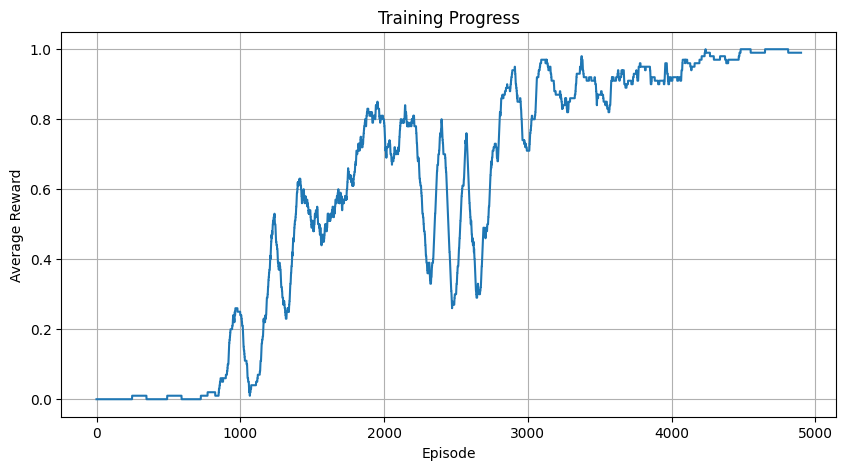

In [78]:
from utils import plot_rewards_curve
plot_rewards_curve(rewards_per_episode)

# 测试环境

In [13]:
dqn_model.test(10)